# Train Supervised CNN Classifier

This notebook is a placeholder for future implementation.

In [2]:
from pathlib import Path
import sys
import os
import shutil
import zipfile

# ------------------------------------------------------------
# 1. Detect Colab and mount Drive
# ------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)

    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/bostongene_project")
    DRIVE_ZIP = DRIVE_PROJECT_DIR / "bostongene_classifier_bundle.zip"

    print("Drive project folder:", DRIVE_PROJECT_DIR)
    print("Expected zip:", DRIVE_ZIP)

    assert DRIVE_PROJECT_DIR.exists(), f"Drive folder not found: {DRIVE_PROJECT_DIR}"
    assert DRIVE_ZIP.exists(), f"Zip file not found: {DRIVE_ZIP}"

    WORK_DIR = Path("/content/bostongene_project")

    # Clean previous extraction
    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)

    WORK_DIR.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------
    # FIX: Custom Unzip to handle Windows backslashes on Linux
    # ------------------------------------------------------------
    print("Extracting and sanitizing Windows paths...")
    with zipfile.ZipFile(DRIVE_ZIP, "r") as zip_ref:
        for member in zip_ref.namelist():
            # Force Windows backslashes to Linux forward slashes
            correct_path = member.replace("\\", "/")
            target_path = WORK_DIR / correct_path

            # If it's a directory (ends with a slash)
            if correct_path.endswith('/'):
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                # Ensure parent directories exist
                target_path.parent.mkdir(parents=True, exist_ok=True)
                # Write the file
                with zip_ref.open(member) as source, open(target_path, "wb") as target:
                    target.write(source.read())

    print("Unzipped into:", WORK_DIR)

else:
    WORK_DIR = Path.cwd().resolve()


# ------------------------------------------------------------
# 2. Find the project root robustly
# ------------------------------------------------------------

# Now that folders are created correctly, search for 'src'
src_dirs = list(WORK_DIR.rglob("src"))

if not src_dirs:
    print(f"\n--- DEBUG: Contents of {WORK_DIR} ---")
    for p in WORK_DIR.rglob("*"):
        print(p)
    raise FileNotFoundError("Could not find the 'src' directory.")

PROJECT_ROOT = src_dirs[0].parent

print("\nProject root explicitly found at:", PROJECT_ROOT)

assert (PROJECT_ROOT / "data").exists(), "Found 'src', but could not find 'data' directory in the same root."


# ------------------------------------------------------------
# 3. Move into project root and set Python path
# ------------------------------------------------------------

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("\nIN_COLAB:", IN_COLAB)
print("Current working directory:", Path.cwd())


# ------------------------------------------------------------
# 4. Verify processed split exists
# ------------------------------------------------------------

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_DIR = PROCESSED_DIR / "train"
VAL_DIR = PROCESSED_DIR / "val"
TEST_DIR = PROCESSED_DIR / "test"

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation folder not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder: Path) -> int:
    return sum(
        1
        for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )

print("\nProcessed split counts:")
print("Train:", count_images(TRAIN_DIR))
print("Val:  ", count_images(VAL_DIR))
print("Test: ", count_images(TEST_DIR))

Mounted at /content/drive
Drive project folder: /content/drive/MyDrive/bostongene_project
Expected zip: /content/drive/MyDrive/bostongene_project/bostongene_classifier_bundle.zip
Extracting and sanitizing Windows paths...
Unzipped into: /content/bostongene_project

Project root explicitly found at: /content/bostongene_project/image_classification_project

IN_COLAB: True
Current working directory: /content/bostongene_project/image_classification_project

Processed split counts:
Train: 995
Val:   213
Test:  214


In [ ]:
!pip -q install pandas matplotlib scikit-learn pillow tqdm

In [6]:
import sys
from pathlib import Path

# Detect project root
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

assert PROJECT_ROOT.name == "image_classification_project", (
    f"Wrong working directory: {PROJECT_ROOT}. "
    "Launch Jupyter from image_classification_project."
)

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /content/bostongene_project/image_classification_project


In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("Device:", device)

Torch version: 2.11.0+cu128
Device: cuda


In [ ]:
from src.data import get_datasets, get_dataloaders, compute_class_weights

train_dataset, val_dataset, test_dataset = get_datasets()

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("Classes:")
print(train_dataset.classes)

print("Class to index:")
print(train_dataset.class_to_idx)

Train images: 995
Validation images: 213
Test images: 214
Classes:
['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']
Class to index:
{'ArtDeco': 0, 'Cubism': 1, 'Impressionism': 2, 'Japonism': 3, 'Naturalism': 4, 'Rococo': 5, 'cartoon': 6, 'photo': 7}


In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=32,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Min pixel value after normalization:", images.min().item())
print("Max pixel value after normalization:", images.max().item())
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Min pixel value after normalization: -2.1179039478302
Max pixel value after normalization: 2.640000104904175
Labels: tensor([5, 0, 1, 6, 1, 2, 0, 3, 2, 4])


In [ ]:
from src.models import SimpleCNN
from src.config import NUM_CLASSES

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model(images)

print("Logits shape:", logits.shape)
print("Expected shape:", (images.shape[0], NUM_CLASSES))

Logits shape: torch.Size([32, 8])
Expected shape: (32, 8)


In [ ]:
import torch.nn as nn

class_weights = compute_class_weights(train_dataset).to(device)

print("Class weights:")
for class_name, weight in zip(train_dataset.classes, class_weights.cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

loss = criterion(logits, labels)

print("Test loss:", loss.item())

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282
Test loss: 2.1100902557373047


## Training Strategy

The first supervised baseline is a lightweight CNN trained from scratch on the processed ImageFolder split.

Because the dataset is imbalanced, the model uses weighted CrossEntropyLoss. The main validation metric is macro-F1, because it gives equal importance to all classes regardless of class size. Balanced accuracy is also tracked.

The model checkpoint is selected using the best validation macro-F1 score.

In [ ]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix

from src.models import SimpleCNN
from src.data import get_dataloaders, get_datasets, compute_class_weights
from src.metrics import compute_metrics
from src.config import NUM_CLASSES, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, SEED


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# Use 0 workers on Windows/local CPU.
# In Colab GPU, 2 workers is usually fine.
NUM_WORKERS = 0 if device.type == "cpu" else 2
BATCH_SIZE = 32

train_dataset, val_dataset, test_dataset = get_datasets()

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

class_names = train_dataset.classes

class_weights = compute_class_weights(train_dataset).to(device)

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

print("Classes:", class_names)
print("Class weights:")
for class_name, weight in zip(class_names, class_weights.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

print(model)

Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']
Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics

In [ ]:
# Local CPU: only smoke test.
# Colab GPU: real training.
EPOCHS = 1 if device.type == "cpu" else 25
PATIENCE = 6

best_val_macro_f1 = -1.0
epochs_without_improvement = 0

history = []

best_model_path = MODELS_DIR / "best_simple_cnn.pt"

print(f"Training for {EPOCHS} epoch(s)")
print(f"Best model will be saved to: {best_model_path}")

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    scheduler.step(val_metrics["macro_f1"])

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1

    if improved:
        best_val_macro_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "val_macro_f1": best_val_macro_f1,
                "config": {
                    "num_classes": NUM_CLASSES,
                    "batch_size": BATCH_SIZE,
                    "img_size": 128,
                    "architecture": "SimpleCNN",
                },
            },
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr={current_lr:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time
print(f"Training finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")

Training for 25 epoch(s)
Best model will be saved to: /content/bostongene_project/image_classification_project/models/best_simple_cnn.pt
Epoch 01/25 | train_loss=1.2838 | train_macro_f1=0.5137 | val_loss=1.3323 | val_macro_f1=0.5186 | val_bal_acc=0.5430 | lr=0.000250 | time=5.3s
Epoch 02/25 | train_loss=1.2540 | train_macro_f1=0.5110 | val_loss=1.3994 | val_macro_f1=0.4672 | val_bal_acc=0.5159 | lr=0.000125 | time=7.4s
Epoch 03/25 | train_loss=1.2845 | train_macro_f1=0.5076 | val_loss=1.3590 | val_macro_f1=0.5172 | val_bal_acc=0.5408 | lr=0.000125 | time=5.4s
Epoch 04/25 | train_loss=1.2368 | train_macro_f1=0.5393 | val_loss=1.3587 | val_macro_f1=0.5258 | val_bal_acc=0.5562 | lr=0.000125 | time=7.1s
Epoch 05/25 | train_loss=1.2136 | train_macro_f1=0.5405 | val_loss=1.3165 | val_macro_f1=0.5106 | val_bal_acc=0.5197 | lr=0.000125 | time=5.3s
Epoch 06/25 | train_loss=1.2218 | train_macro_f1=0.5243 | val_loss=1.3485 | val_macro_f1=0.5184 | val_bal_acc=0.5515 | lr=0.000125 | time=5.8s
Epoch

In [ ]:
history_df = pd.DataFrame(history)

history_path = OUTPUTS_DIR / "simple_cnn_training_history.csv"
history_df.to_csv(history_path, index=False)

display(history_df)

print(f"Saved training history to: {history_path}")

,epoch,lr,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.000250,1.283763,0.526633,0.513675,0.555950,1.332335,0.530516,0.518595,0.543013
1,2,0.000125,1.254035,0.526633,0.511011,0.549122,1.399386,0.488263,0.467247,0.515895
2,3,0.000125,1.284462,0.523618,0.507624,0.544398,1.358955,0.535211,0.517236,0.540801
3,4,0.000125,1.236803,0.552764,0.539337,0.578138,1.358737,0.535211,0.525773,0.556200
4,5,0.000125,1.213588,0.550754,0.540517,0.575703,1.316548,0.530516,0.510586,0.519669
5,6,0.000125,1.221778,0.544724,0.524277,0.561725,1.348467,0.530516,0.518378,0.551461
6,7,0.000125,1.205324,0.554774,0.544886,0.588067,1.322753,0.544601,0.523184,0.551093
7,8,0.000063,1.200401,0.563819,0.548870,0.580856,1.304229,0.521127,0.494771,0.500607
8,9,0.000063,1.198686,0.563819,0.548958,0.579670,1.323215,0.568075,0.540662,0.566611
9,10,0.000063,1.193877,0.557789,0.549694,0.587209,1.286113,0.553991,0.533533,0.550763


Saved training history to: /content/bostongene_project/image_classification_project/outputs/simple_cnn_training_history.csv


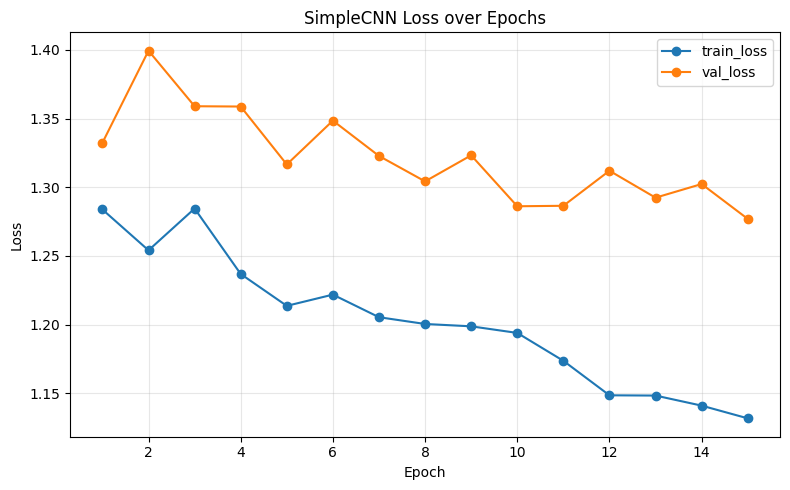

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/05_simple_cnn_loss_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

ax.set_title("SimpleCNN Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

loss_fig_path = FIGURES_DIR / "05_simple_cnn_loss_curve.png"
fig.savefig(loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {loss_fig_path}")

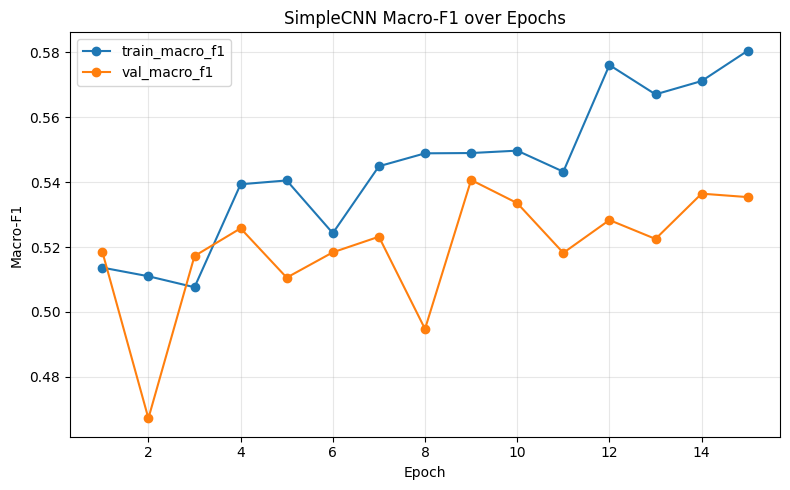

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/06_simple_cnn_macro_f1_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
ax.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")

ax.set_title("SimpleCNN Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

f1_fig_path = FIGURES_DIR / "06_simple_cnn_macro_f1_curve.png"
fig.savefig(f1_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {f1_fig_path}")

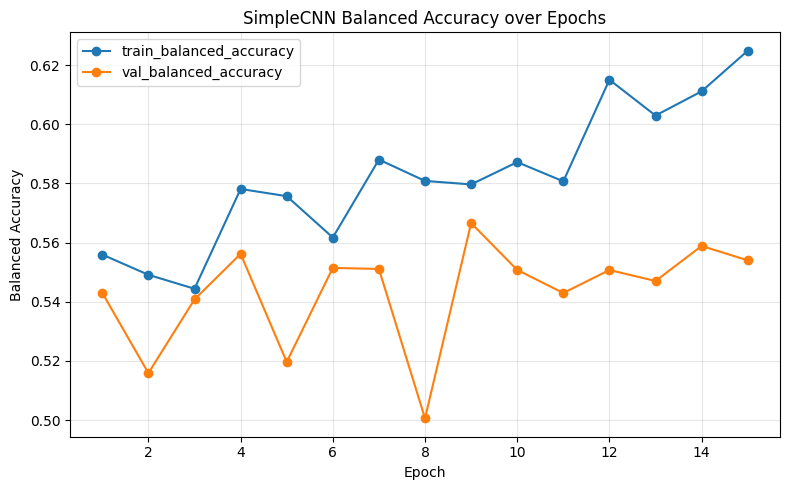

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/07_simple_cnn_balanced_accuracy_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_balanced_accuracy"],
    marker="o",
    label="train_balanced_accuracy",
)

ax.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    marker="o",
    label="val_balanced_accuracy",
)

ax.set_title("SimpleCNN Balanced Accuracy over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

bal_acc_fig_path = FIGURES_DIR / "07_simple_cnn_balanced_accuracy_curve.png"
fig.savefig(bal_acc_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {bal_acc_fig_path}")

In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

test_metrics, y_true, y_pred = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint["val_macro_f1"])

print("\nTest metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 9
Validation macro-F1 at checkpoint: 0.540661522831306

Test metrics:
accuracy: 0.5421
macro_f1: 0.4947
balanced_accuracy: 0.5174
loss: 1.2679


In [ ]:
report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

print(report_text)

report_path = OUTPUTS_DIR / "simple_cnn_test_classification_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Saved classification report to: {report_path}")

               precision    recall  f1-score   support

      ArtDeco       0.20      0.22      0.21         9
       Cubism       0.74      0.56      0.64        55
Impressionism       0.55      0.31      0.39        36
     Japonism       0.51      0.71      0.59        31
   Naturalism       0.56      0.61      0.58        33
       Rococo       0.52      0.61      0.56        18
      cartoon       0.38      0.45      0.42        11
        photo       0.48      0.67      0.56        21

     accuracy                           0.54       214
    macro avg       0.49      0.52      0.49       214
 weighted avg       0.56      0.54      0.54       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/simple_cnn_test_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,2,1,0,3,2,0,0,1
Cubism,3,31,1,10,4,1,3,2
Impressionism,0,4,11,6,7,3,0,5
Japonism,1,2,3,22,0,1,2,0
Naturalism,1,1,4,2,20,1,0,4
Rococo,1,1,1,0,1,11,1,2
cartoon,1,2,0,0,1,1,5,1
photo,1,0,0,0,1,3,2,14


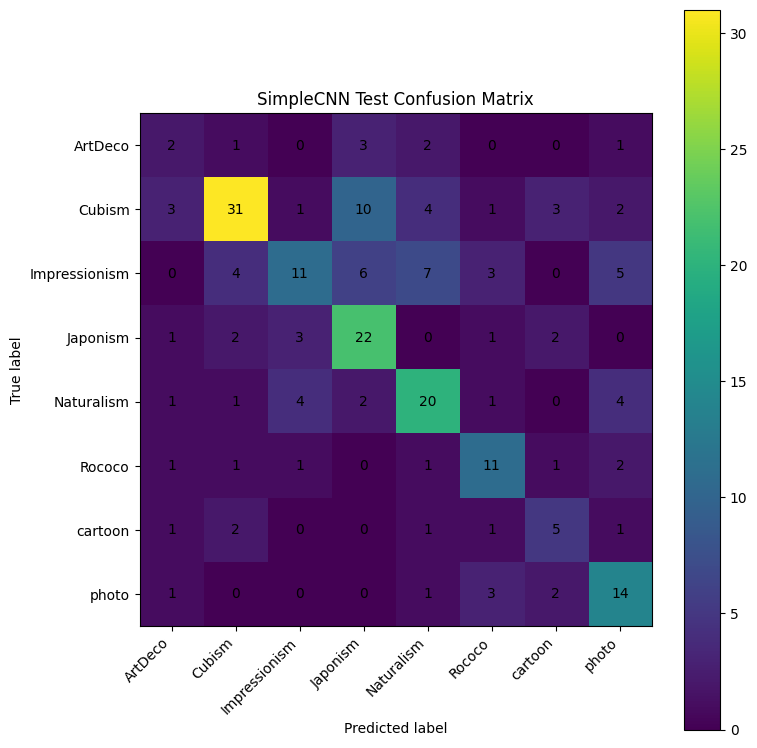

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/simple_cnn_test_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/08_simple_cnn_test_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

cm_path = OUTPUTS_DIR / "simple_cnn_test_confusion_matrix.csv"
cm_df.to_csv(cm_path)

display(cm_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm)

ax.set_title("SimpleCNN Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path = FIGURES_DIR / "08_simple_cnn_test_confusion_matrix.png"
fig.savefig(cm_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path}")
print(f"Saved confusion matrix figure to: {cm_fig_path}")

In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/classifier_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved classifier results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/classifier_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/classifier_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/classifier_results/reports
Saved classifier results to Google Drive: /content/drive/MyDrive/bostongene_project/classifier_results


## ResNet18 Transfer Learning Classifier

The SimpleCNN model trained from scratch is used as the first baseline. Since the dataset is small and imbalanced, a stronger transfer-learning baseline is added using ResNet18 pretrained on ImageNet.

The input size is kept at 128x128 to satisfy the project requirement. The model uses class-weighted CrossEntropyLoss with label smoothing.

In [ ]:
from pathlib import Path
import sys
import os
import shutil
import zipfile

# ============================================================
# 1. Mount Drive and locate zip
# ============================================================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/bostongene_project")
    DRIVE_ZIP = DRIVE_PROJECT_DIR / "bostongene_classifier_bundle.zip"

    print("Drive project folder:", DRIVE_PROJECT_DIR)
    print("Expected zip:", DRIVE_ZIP)

    assert DRIVE_PROJECT_DIR.exists(), f"Drive folder not found: {DRIVE_PROJECT_DIR}"
    assert DRIVE_ZIP.exists(), f"Zip file not found: {DRIVE_ZIP}"

    WORK_DIR = Path("/content/bostongene_project")

    # Clean previous extraction
    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)

    WORK_DIR.mkdir(parents=True, exist_ok=True)

    # ============================================================
    # 2. Extract zip safely
    # This handles Windows-style backslashes inside the zip.
    # ============================================================

    print("Extracting and sanitizing Windows paths...")

    with zipfile.ZipFile(DRIVE_ZIP, "r") as zip_ref:
        for member in zip_ref.namelist():
            # Convert Windows backslashes to Linux forward slashes
            correct_path = member.replace("\\", "/")
            target_path = WORK_DIR / correct_path

            if correct_path.endswith("/"):
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)

                with zip_ref.open(member) as source, open(target_path, "wb") as target:
                    target.write(source.read())

    print("Unzipped into:", WORK_DIR)

else:
    WORK_DIR = Path.cwd().resolve()


# ============================================================
# 3. Find project root
# ============================================================

src_dirs = list(WORK_DIR.rglob("src"))

print("\nFound src directories:")
for p in src_dirs:
    print(" -", p)

assert len(src_dirs) > 0, (
    "Could not find src directory. "
    "The zip may not contain image_classification_project/src."
)

# Usually the correct project root is the parent of src/
PROJECT_ROOT = src_dirs[0].parent

print("\nProject root found at:", PROJECT_ROOT)

assert (PROJECT_ROOT / "data").exists(), "Found src, but data/ is missing."
assert (PROJECT_ROOT / "notebooks").exists(), "Found src, but notebooks/ is missing."
assert (PROJECT_ROOT / "src" / "data.py").exists(), "src/data.py is missing."
assert (PROJECT_ROOT / "src" / "config.py").exists(), "src/config.py is missing."


# ============================================================
# 4. Move into project root and set import path
# ============================================================

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("\nIN_COLAB:", IN_COLAB)
print("Current working directory:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)


# ============================================================
# 5. Test imports
# ============================================================

from src.data import PadToSquare, compute_class_weights
from src.config import TRAIN_DIR, VAL_DIR, TEST_DIR, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, NUM_CLASSES

print("\nImport test passed.")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)


# ============================================================
# 6. Verify processed split
# ============================================================

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder: Path) -> int:
    return sum(
        1
        for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )

print("\nProcessed split counts:")
print("Train:", count_images(TRAIN_DIR))
print("Val:  ", count_images(VAL_DIR))
print("Test: ", count_images(TEST_DIR))

Mounted at /content/drive
Drive project folder: /content/drive/MyDrive/bostongene_project
Expected zip: /content/drive/MyDrive/bostongene_project/bostongene_classifier_bundle.zip
Extracting and sanitizing Windows paths...
Unzipped into: /content/bostongene_project

Found src directories:
 - /content/bostongene_project/image_classification_project/src

Project root found at: /content/bostongene_project/image_classification_project

IN_COLAB: True
Current working directory: /content/bostongene_project/image_classification_project
PROJECT_ROOT: /content/bostongene_project/image_classification_project

Import test passed.
TRAIN_DIR: /content/bostongene_project/image_classification_project/data/processed/train
VAL_DIR: /content/bostongene_project/image_classification_project/data/processed/val
TEST_DIR: /content/bostongene_project/image_classification_project/data/processed/test

Processed split counts:
Train: 995
Val:   213
Test:  214


In [ ]:
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Define device BEFORE using it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from src.data import PadToSquare, compute_class_weights
from src.config import (
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    NUM_CLASSES,
)

IMG_SIZE_TL = 128
BATCH_SIZE_TL = 32
NUM_WORKERS_TL = 2 if device.type == "cuda" else 0
train_transform_tl = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform_tl = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_TL, IMG_SIZE_TL)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset_tl = datasets.ImageFolder(TRAIN_DIR, transform=train_transform_tl)
val_dataset_tl = datasets.ImageFolder(VAL_DIR, transform=eval_transform_tl)
test_dataset_tl = datasets.ImageFolder(TEST_DIR, transform=eval_transform_tl)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=BATCH_SIZE_TL,
    shuffle=True,
    num_workers=NUM_WORKERS_TL,
    pin_memory=(device.type == "cuda"),
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=BATCH_SIZE_TL,
    shuffle=False,
    num_workers=NUM_WORKERS_TL,
    pin_memory=(device.type == "cuda"),
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=BATCH_SIZE_TL,
    shuffle=False,
    num_workers=NUM_WORKERS_TL,
    pin_memory=(device.type == "cuda"),
)

class_names_tl = train_dataset_tl.classes

print("Device:", device)
print("Image size:", IMG_SIZE_TL)
print("Train images:", len(train_dataset_tl))
print("Validation images:", len(val_dataset_tl))
print("Test images:", len(test_dataset_tl))
print("Classes:", class_names_tl)

Device: cuda
Device: cuda
Image size: 128
Train images: 995
Validation images: 213
Test images: 214
Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


In [ ]:
weights = ResNet18_Weights.IMAGENET1K_V1

model_tl = resnet18(weights=weights)

# Replace final classification layer
in_features = model_tl.fc.in_features

model_tl.fc = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, NUM_CLASSES),
)

model_tl = model_tl.to(device)

class_weights_tl = compute_class_weights(train_dataset_tl).to(device)

# Final selected supervised loss:
# weighted CE handles imbalance, label smoothing reduces overconfidence.
criterion_tl = nn.CrossEntropyLoss(
    weight=class_weights_tl,
    label_smoothing=0.05,
)

# Use smaller learning rate for pretrained backbone,
# larger learning rate for new classification head.
backbone_params = []
head_params = []

for name, param in model_tl.named_parameters():
    if name.startswith("fc"):
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer_tl = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-4},
        {"params": head_params, "lr": 7e-4},
    ],
    weight_decay=1e-4,
)

scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl,
    mode="max",
    factor=0.5,
    patience=3,
)

print("ResNet18 classifier head:")
print(model_tl.fc)

print("\nClass weights:")
for class_name, weight in zip(class_names_tl, class_weights_tl.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


ResNet18 classifier head:
Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=512, out_features=8, bias=True)
)

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282


In [ ]:
from src.metrics import compute_metrics
import torch


def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train model for one epoch.
    Returns loss, accuracy, macro-F1, and balanced accuracy.
    """
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    """
    Evaluate model on validation or test set.
    Returns loss, accuracy, macro-F1, and balanced accuracy.
    """
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


print("train_one_epoch and evaluate are defined.")

train_one_epoch and evaluate are defined.


In [ ]:
EPOCHS_TL = 25
PATIENCE_TL = 6

best_val_macro_f1_tl = -1.0
epochs_without_improvement_tl = 0

history_tl = []

best_model_path_tl = MODELS_DIR / "best_resnet18_transfer.pt"

print(f"Training ResNet18 transfer model for {EPOCHS_TL} epochs")
print(f"Best model will be saved to: {best_model_path_tl}")

start_time = time.time()

for epoch in range(1, EPOCHS_TL + 1):
    epoch_start = time.time()

    train_metrics = train_one_epoch(
        model=model_tl,
        loader=train_loader_tl,
        criterion=criterion_tl,
        optimizer=optimizer_tl,
        device=device,
    )

    val_metrics = evaluate(
        model=model_tl,
        loader=val_loader_tl,
        criterion=criterion_tl,
        device=device,
    )

    scheduler_tl.step(val_metrics["macro_f1"])

    current_lr_backbone = optimizer_tl.param_groups[0]["lr"]
    current_lr_head = optimizer_tl.param_groups[1]["lr"]

    row = {
        "epoch": epoch,
        "lr_backbone": current_lr_backbone,
        "lr_head": current_lr_head,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history_tl.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1_tl

    if improved:
        best_val_macro_f1_tl = val_metrics["macro_f1"]
        epochs_without_improvement_tl = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_tl.state_dict(),
                "optimizer_state_dict": optimizer_tl.state_dict(),
                "class_names": class_names_tl,
                "val_macro_f1": best_val_macro_f1_tl,
                "config": {
                    "num_classes": NUM_CLASSES,
                    "batch_size": BATCH_SIZE_TL,
                    "img_size": IMG_SIZE_TL,
                    "architecture": "ResNet18 pretrained on ImageNet",
                    "loss": "Weighted CrossEntropyLoss with label_smoothing=0.05",
                },
            },
            best_model_path_tl,
        )
    else:
        epochs_without_improvement_tl += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS_TL} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr_backbone={current_lr_backbone:.6f} | "
        f"lr_head={current_lr_head:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement_tl >= PATIENCE_TL:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time

print(f"Transfer learning finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1_tl:.4f}")

Training ResNet18 transfer model for 25 epochs
Best model will be saved to: /content/bostongene_project/image_classification_project/models/best_resnet18_transfer.pt
Epoch 01/25 | train_loss=1.8969 | train_macro_f1=0.3335 | val_loss=1.5519 | val_macro_f1=0.5046 | val_bal_acc=0.5532 | lr_backbone=0.000100 | lr_head=0.000700 | time=7.9s
Epoch 02/25 | train_loss=1.1484 | train_macro_f1=0.6522 | val_loss=1.3814 | val_macro_f1=0.5803 | val_bal_acc=0.6444 | lr_backbone=0.000100 | lr_head=0.000700 | time=7.6s
Epoch 03/25 | train_loss=0.9738 | train_macro_f1=0.7089 | val_loss=1.2479 | val_macro_f1=0.5962 | val_bal_acc=0.6308 | lr_backbone=0.000100 | lr_head=0.000700 | time=5.8s
Epoch 04/25 | train_loss=0.7716 | train_macro_f1=0.8090 | val_loss=1.2052 | val_macro_f1=0.6529 | val_bal_acc=0.6812 | lr_backbone=0.000100 | lr_head=0.000700 | time=7.7s
Epoch 05/25 | train_loss=0.6862 | train_macro_f1=0.8695 | val_loss=1.1963 | val_macro_f1=0.6505 | val_bal_acc=0.6812 | lr_backbone=0.000100 | lr_head=

In [ ]:
history_tl_df = pd.DataFrame(history_tl)

history_tl_path = OUTPUTS_DIR / "resnet18_transfer_training_history.csv"
history_tl_df.to_csv(history_tl_path, index=False)

display(history_tl_df)

print(f"Saved transfer-learning history to: {history_tl_path}")

,epoch,lr_backbone,lr_head,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.000100,0.000700,1.896874,0.345729,0.333484,0.370308,1.551876,0.516432,0.504565,0.553199
1,2,0.000100,0.000700,1.148388,0.667337,0.652220,0.684699,1.381367,0.591549,0.580260,0.644423
2,3,0.000100,0.000700,0.973754,0.717588,0.708940,0.745077,1.247877,0.629108,0.596234,0.630835
3,4,0.000100,0.000700,0.771555,0.808040,0.808972,0.852394,1.205163,0.690141,0.652905,0.681232
4,5,0.000100,0.000700,0.686160,0.861307,0.869451,0.893981,1.196263,0.680751,0.650524,0.681232
5,6,0.000100,0.000700,0.664439,0.855276,0.862425,0.886854,1.204167,0.671362,0.641995,0.678535
6,7,0.000100,0.000700,0.560139,0.932663,0.932282,0.949876,1.244247,0.699531,0.658246,0.690568
7,8,0.000100,0.000700,0.554283,0.925628,0.928416,0.938229,1.268708,0.671362,0.639856,0.682848
8,9,0.000100,0.000700,0.546831,0.924623,0.932276,0.941356,1.287692,0.661972,0.631552,0.672327
9,10,0.000100,0.000700,0.533365,0.940704,0.934471,0.950085,1.297830,0.690141,0.649882,0.668873


Saved transfer-learning history to: /content/bostongene_project/image_classification_project/outputs/resnet18_transfer_training_history.csv


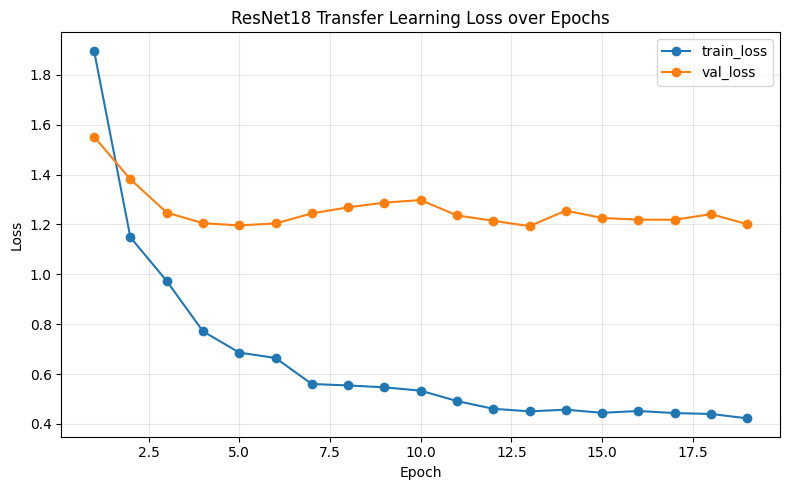

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/09_resnet18_transfer_loss_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_tl_df["epoch"], history_tl_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_tl_df["epoch"], history_tl_df["val_loss"], marker="o", label="val_loss")

ax.set_title("ResNet18 Transfer Learning Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

loss_fig_path_tl = FIGURES_DIR / "09_resnet18_transfer_loss_curve.png"
fig.savefig(loss_fig_path_tl, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {loss_fig_path_tl}")

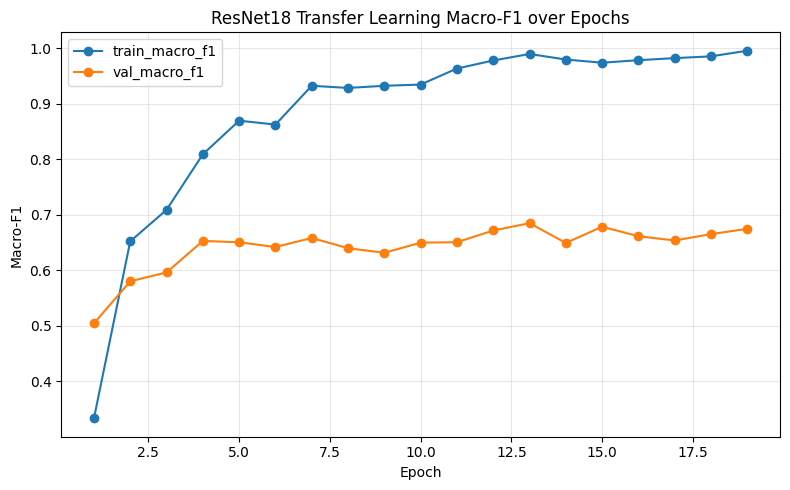

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/10_resnet18_transfer_macro_f1_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_tl_df["epoch"],
    history_tl_df["train_macro_f1"],
    marker="o",
    label="train_macro_f1",
)

ax.plot(
    history_tl_df["epoch"],
    history_tl_df["val_macro_f1"],
    marker="o",
    label="val_macro_f1",
)

ax.set_title("ResNet18 Transfer Learning Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

f1_fig_path_tl = FIGURES_DIR / "10_resnet18_transfer_macro_f1_curve.png"
fig.savefig(f1_fig_path_tl, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {f1_fig_path_tl}")

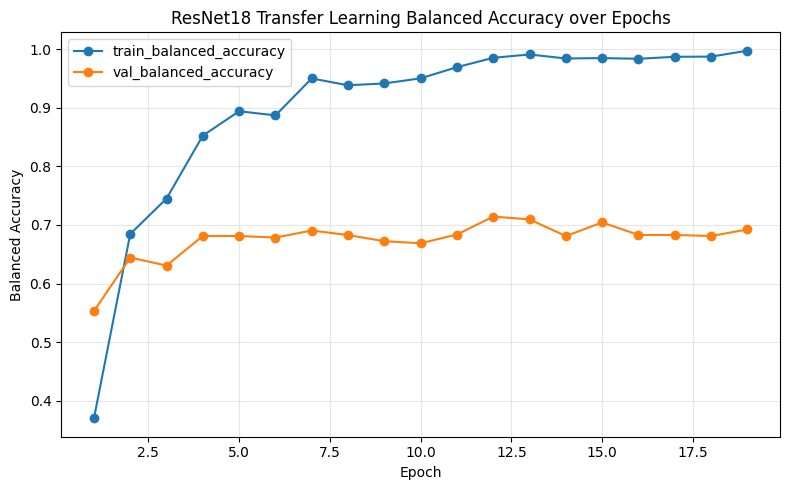

Saved figure to: /content/bostongene_project/image_classification_project/reports/figures/11_resnet18_transfer_balanced_accuracy_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_tl_df["epoch"],
    history_tl_df["train_balanced_accuracy"],
    marker="o",
    label="train_balanced_accuracy",
)

ax.plot(
    history_tl_df["epoch"],
    history_tl_df["val_balanced_accuracy"],
    marker="o",
    label="val_balanced_accuracy",
)

ax.set_title("ResNet18 Transfer Learning Balanced Accuracy over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

bal_acc_fig_path_tl = FIGURES_DIR / "11_resnet18_transfer_balanced_accuracy_curve.png"
fig.savefig(bal_acc_fig_path_tl, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {bal_acc_fig_path_tl}")

In [ ]:
checkpoint_tl = torch.load(best_model_path_tl, map_location=device)

model_tl = resnet18(weights=None)

in_features = model_tl.fc.in_features
model_tl.fc = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, NUM_CLASSES),
)

model_tl = model_tl.to(device)
model_tl.load_state_dict(checkpoint_tl["model_state_dict"])

test_metrics_tl, y_true_tl, y_pred_tl = evaluate(
    model=model_tl,
    loader=test_loader_tl,
    criterion=criterion_tl,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint_tl["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint_tl["val_macro_f1"])

print("\nResNet18 transfer-learning test metrics:")
for key, value in test_metrics_tl.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 13
Validation macro-F1 at checkpoint: 0.6848858707798187

ResNet18 transfer-learning test metrics:
accuracy: 0.7570
macro_f1: 0.7324
balanced_accuracy: 0.7629
loss: 1.0925


In [ ]:
from sklearn.metrics import classification_report

report_text_tl = classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=class_names_tl,
    zero_division=0,
)

print(report_text_tl)

report_path_tl = OUTPUTS_DIR / "resnet18_transfer_test_classification_report.txt"

with open(report_path_tl, "w", encoding="utf-8") as f:
    f.write(report_text_tl)

print(f"Saved classification report to: {report_path_tl}")

               precision    recall  f1-score   support

      ArtDeco       0.50      0.67      0.57         9
       Cubism       0.84      0.78      0.81        55
Impressionism       0.80      0.67      0.73        36
     Japonism       0.74      0.74      0.74        31
   Naturalism       0.81      0.76      0.78        33
       Rococo       0.68      0.72      0.70        18
      cartoon       0.50      0.91      0.65        11
        photo       0.90      0.86      0.88        21

     accuracy                           0.76       214
    macro avg       0.72      0.76      0.73       214
 weighted avg       0.78      0.76      0.76       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/resnet18_transfer_test_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,6,2,0,0,0,0,1,0
Cubism,4,43,1,2,1,0,4,0
Impressionism,0,1,24,4,1,4,2,0
Japonism,1,2,2,23,1,0,1,1
Naturalism,1,2,1,1,25,1,1,1
Rococo,0,0,2,1,2,13,0,0
cartoon,0,1,0,0,0,0,10,0
photo,0,0,0,0,1,1,1,18


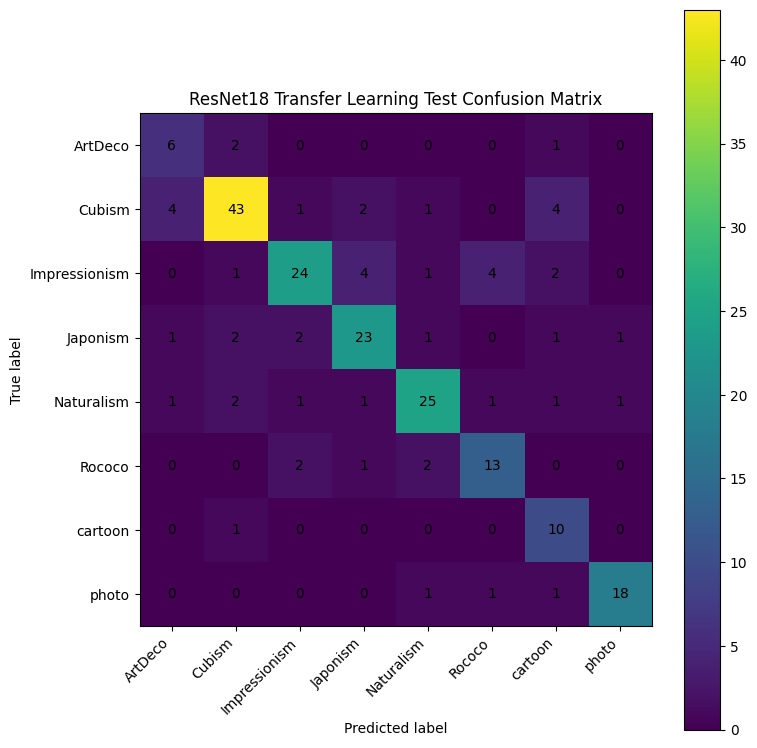

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/resnet18_transfer_test_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/12_resnet18_transfer_test_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

cm_tl_df = pd.DataFrame(
    cm_tl,
    index=class_names_tl,
    columns=class_names_tl,
)

cm_path_tl = OUTPUTS_DIR / "resnet18_transfer_test_confusion_matrix.csv"
cm_tl_df.to_csv(cm_path_tl)

display(cm_tl_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_tl)

ax.set_title("ResNet18 Transfer Learning Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names_tl)))
ax.set_yticks(np.arange(len(class_names_tl)))

ax.set_xticklabels(class_names_tl, rotation=45, ha="right")
ax.set_yticklabels(class_names_tl)

for i in range(cm_tl.shape[0]):
    for j in range(cm_tl.shape[1]):
        ax.text(j, i, str(cm_tl[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path_tl = FIGURES_DIR / "12_resnet18_transfer_test_confusion_matrix.png"
fig.savefig(cm_fig_path_tl, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path_tl}")
print(f"Saved confusion matrix figure to: {cm_fig_path_tl}")

In [ ]:
# If SimpleCNN test_metrics variable exists, use it.
# Otherwise use the values from your completed SimpleCNN experiment.

if "test_metrics" in globals():
    simple_accuracy = test_metrics["accuracy"]
    simple_macro_f1 = test_metrics["macro_f1"]
    simple_balanced_accuracy = test_metrics["balanced_accuracy"]
else:
    simple_accuracy = 0.5421
    simple_macro_f1 = 0.4947
    simple_balanced_accuracy = 0.5174

comparison_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss",
        "test_accuracy": simple_accuracy,
        "test_macro_f1": simple_macro_f1,
        "test_balanced_accuracy": simple_balanced_accuracy,
    },
    {
        "model": "ResNet18 transfer learning",
        "input_size": IMG_SIZE_TL,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": test_metrics_tl["accuracy"],
        "test_macro_f1": test_metrics_tl["macro_f1"],
        "test_balanced_accuracy": test_metrics_tl["balanced_accuracy"],
    },
])

comparison_path = OUTPUTS_DIR / "classifier_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)

print(f"Saved comparison table to: {comparison_path}")

,model,input_size,loss,test_accuracy,test_macro_f1,test_balanced_accuracy
0,SimpleCNN from scratch,128,Weighted CrossEntropyLoss,0.542100,0.49470,0.51740
1,ResNet18 transfer learning,128,Weighted CrossEntropyLoss + label smoothing,0.757009,0.73239,0.76289


Saved comparison table to: /content/bostongene_project/image_classification_project/outputs/classifier_comparison.csv


In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/classifier_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved updated classifier results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/classifier_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/classifier_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/classifier_results/reports
Saved updated classifier results to Google Drive: /content/drive/MyDrive/bostongene_project/classifier_results


## EfficientNet-B0 Transfer Learning

The ResNet18 transfer-learning model gave the strongest supervised result so far. To check whether the supervised classifier can be improved further, we add a second pretrained architecture: EfficientNet-B0.

EfficientNet-B0 is lightweight enough for Colab and often performs well on small image-classification datasets. The input size is kept at 128x128 to stay aligned with the project requirement.

The model uses:

- ImageNet-pretrained EfficientNet-B0 backbone,
- class-weighted CrossEntropyLoss,
- label smoothing,
- validation macro-F1 for checkpoint selection.

In [ ]:
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from src.data import PadToSquare, compute_class_weights
from src.metrics import compute_metrics
from src.config import (
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    NUM_CLASSES,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMG_SIZE_EFF = 128
BATCH_SIZE_EFF = 32
NUM_WORKERS_EFF = 2 if device.type == "cuda" else 0

train_transform_eff = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.12,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform_eff = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_EFF, IMG_SIZE_EFF)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset_eff = datasets.ImageFolder(TRAIN_DIR, transform=train_transform_eff)
val_dataset_eff = datasets.ImageFolder(VAL_DIR, transform=eval_transform_eff)
test_dataset_eff = datasets.ImageFolder(TEST_DIR, transform=eval_transform_eff)

train_loader_eff = DataLoader(
    train_dataset_eff,
    batch_size=BATCH_SIZE_EFF,
    shuffle=True,
    num_workers=NUM_WORKERS_EFF,
    pin_memory=(device.type == "cuda"),
)

val_loader_eff = DataLoader(
    val_dataset_eff,
    batch_size=BATCH_SIZE_EFF,
    shuffle=False,
    num_workers=NUM_WORKERS_EFF,
    pin_memory=(device.type == "cuda"),
)

test_loader_eff = DataLoader(
    test_dataset_eff,
    batch_size=BATCH_SIZE_EFF,
    shuffle=False,
    num_workers=NUM_WORKERS_EFF,
    pin_memory=(device.type == "cuda"),
)

class_names_eff = train_dataset_eff.classes

print("Train images:", len(train_dataset_eff))
print("Validation images:", len(val_dataset_eff))
print("Test images:", len(test_dataset_eff))
print("Classes:", class_names_eff)

Device: cuda
Train images: 995
Validation images: 213
Test images: 214
Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


In [ ]:
from src.metrics import compute_metrics
import torch


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


print("Training and evaluation functions are ready.")

Training and evaluation functions are ready.


In [ ]:
weights_eff = EfficientNet_B0_Weights.IMAGENET1K_V1

model_eff = efficientnet_b0(weights=weights_eff)

# EfficientNet-B0 classifier structure usually:
# model_eff.classifier = Sequential(Dropout, Linear)
in_features = model_eff.classifier[1].in_features

model_eff.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, NUM_CLASSES),
)

model_eff = model_eff.to(device)

class_weights_eff = compute_class_weights(train_dataset_eff).to(device)

criterion_eff = nn.CrossEntropyLoss(
    weight=class_weights_eff,
    label_smoothing=0.05,
)

# Differential learning rates:
# pretrained feature extractor gets lower LR,
# new classifier head gets higher LR.
backbone_params = []
head_params = []

for name, param in model_eff.named_parameters():
    if name.startswith("classifier"):
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer_eff = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 7e-5},
        {"params": head_params, "lr": 7e-4},
    ],
    weight_decay=1e-4,
)

scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_eff,
    mode="max",
    factor=0.5,
    patience=3,
)

print("EfficientNet-B0 classifier head:")
print(model_eff.classifier)

print("\nClass weights:")
for class_name, weight in zip(class_names_eff, class_weights_eff.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 106MB/s] 


EfficientNet-B0 classifier head:
Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282


In [ ]:
EPOCHS_EFF = 25
PATIENCE_EFF = 6

best_val_macro_f1_eff = -1.0
epochs_without_improvement_eff = 0

history_eff = []

best_model_path_eff = MODELS_DIR / "best_efficientnet_b0_transfer.pt"

print(f"Training EfficientNet-B0 transfer model for {EPOCHS_EFF} epochs")
print(f"Best model will be saved to: {best_model_path_eff}")

start_time = time.time()

for epoch in range(1, EPOCHS_EFF + 1):
    epoch_start = time.time()

    train_metrics = train_one_epoch(
        model=model_eff,
        loader=train_loader_eff,
        criterion=criterion_eff,
        optimizer=optimizer_eff,
        device=device,
    )

    val_metrics = evaluate(
        model=model_eff,
        loader=val_loader_eff,
        criterion=criterion_eff,
        device=device,
    )

    scheduler_eff.step(val_metrics["macro_f1"])

    current_lr_backbone = optimizer_eff.param_groups[0]["lr"]
    current_lr_head = optimizer_eff.param_groups[1]["lr"]

    row = {
        "epoch": epoch,
        "lr_backbone": current_lr_backbone,
        "lr_head": current_lr_head,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history_eff.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1_eff

    if improved:
        best_val_macro_f1_eff = val_metrics["macro_f1"]
        epochs_without_improvement_eff = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_eff.state_dict(),
                "optimizer_state_dict": optimizer_eff.state_dict(),
                "class_names": class_names_eff,
                "val_macro_f1": best_val_macro_f1_eff,
                "config": {
                    "num_classes": NUM_CLASSES,
                    "batch_size": BATCH_SIZE_EFF,
                    "img_size": IMG_SIZE_EFF,
                    "architecture": "EfficientNet-B0 pretrained on ImageNet",
                    "loss": "Weighted CrossEntropyLoss with label_smoothing=0.05",
                },
            },
            best_model_path_eff,
        )
    else:
        epochs_without_improvement_eff += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS_EFF} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr_backbone={current_lr_backbone:.6f} | "
        f"lr_head={current_lr_head:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement_eff >= PATIENCE_EFF:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time

print(f"EfficientNet-B0 training finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1_eff:.4f}")

Training EfficientNet-B0 transfer model for 25 epochs
Best model will be saved to: /content/bostongene_project/image_classification_project/models/best_efficientnet_b0_transfer.pt
Epoch 01/25 | train_loss=1.9694 | train_macro_f1=0.2787 | val_loss=1.8022 | val_macro_f1=0.4749 | val_bal_acc=0.5375 | lr_backbone=0.000070 | lr_head=0.000700 | time=12.1s
Epoch 02/25 | train_loss=1.5308 | train_macro_f1=0.5298 | val_loss=1.5307 | val_macro_f1=0.5542 | val_bal_acc=0.6048 | lr_backbone=0.000070 | lr_head=0.000700 | time=6.1s
Epoch 03/25 | train_loss=1.2621 | train_macro_f1=0.6371 | val_loss=1.3484 | val_macro_f1=0.5930 | val_bal_acc=0.6392 | lr_backbone=0.000070 | lr_head=0.000700 | time=8.0s
Epoch 04/25 | train_loss=1.0963 | train_macro_f1=0.6752 | val_loss=1.2572 | val_macro_f1=0.6312 | val_bal_acc=0.6748 | lr_backbone=0.000070 | lr_head=0.000700 | time=6.4s
Epoch 05/25 | train_loss=1.0020 | train_macro_f1=0.7000 | val_loss=1.1930 | val_macro_f1=0.6387 | val_bal_acc=0.6696 | lr_backbone=0.00

,epoch,lr_backbone,lr_head,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.000070,0.000700,1.969449,0.302513,0.278664,0.302996,1.802229,0.488263,0.474920,0.537547
1,2,0.000070,0.000700,1.530765,0.544724,0.529764,0.579447,1.530721,0.563380,0.554173,0.604820
2,3,0.000070,0.000700,1.262093,0.648241,0.637149,0.681276,1.348383,0.610329,0.592968,0.639167
3,4,0.000070,0.000700,1.096288,0.684422,0.675228,0.720346,1.257238,0.643192,0.631201,0.674825
4,5,0.000070,0.000700,1.001970,0.711558,0.699972,0.742569,1.193007,0.657277,0.638741,0.669552
5,6,0.000070,0.000700,0.877338,0.770854,0.765312,0.803084,1.154237,0.704225,0.686130,0.719694
6,7,0.000070,0.000700,0.802973,0.792965,0.791104,0.825495,1.120611,0.713615,0.684115,0.708693
7,8,0.000070,0.000700,0.732836,0.823116,0.826636,0.860957,1.127691,0.723005,0.699906,0.728023
8,9,0.000070,0.000700,0.691522,0.851256,0.857110,0.878931,1.092518,0.751174,0.731924,0.761001
9,10,0.000070,0.000700,0.661717,0.878392,0.880415,0.907842,1.084560,0.718310,0.697106,0.719625


Saved EfficientNet-B0 training history to: /content/bostongene_project/image_classification_project/outputs/efficientnet_b0_training_history.csv


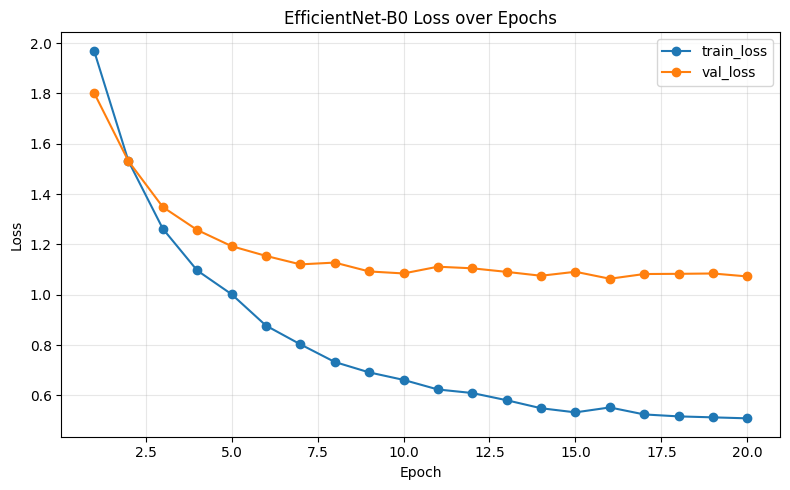

Saved loss curve to: /content/bostongene_project/image_classification_project/reports/figures/28_efficientnet_b0_loss_curve.png


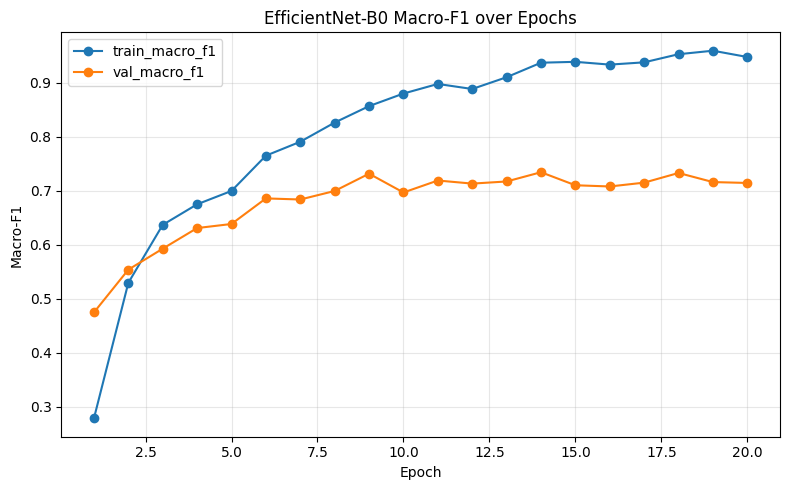

Saved macro-F1 curve to: /content/bostongene_project/image_classification_project/reports/figures/29_efficientnet_b0_macro_f1_curve.png


In [ ]:
history_eff_df = pd.DataFrame(history_eff)

history_eff_path = OUTPUTS_DIR / "efficientnet_b0_training_history.csv"
history_eff_df.to_csv(history_eff_path, index=False)

display(history_eff_df)

print(f"Saved EfficientNet-B0 training history to: {history_eff_path}")


# Loss curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_eff_df["epoch"], history_eff_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_eff_df["epoch"], history_eff_df["val_loss"], marker="o", label="val_loss")

ax.set_title("EfficientNet-B0 Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

eff_loss_fig_path = FIGURES_DIR / "28_efficientnet_b0_loss_curve.png"
fig.savefig(eff_loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved loss curve to: {eff_loss_fig_path}")


# Macro-F1 curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_eff_df["epoch"], history_eff_df["train_macro_f1"], marker="o", label="train_macro_f1")
ax.plot(history_eff_df["epoch"], history_eff_df["val_macro_f1"], marker="o", label="val_macro_f1")

ax.set_title("EfficientNet-B0 Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

eff_f1_fig_path = FIGURES_DIR / "29_efficientnet_b0_macro_f1_curve.png"
fig.savefig(eff_f1_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved macro-F1 curve to: {eff_f1_fig_path}")

In [ ]:
from torchvision.models import efficientnet_b0
from sklearn.metrics import classification_report, confusion_matrix

checkpoint_eff = torch.load(best_model_path_eff, map_location=device)

model_eff_eval = efficientnet_b0(weights=None)

in_features = model_eff_eval.classifier[1].in_features

model_eff_eval.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, NUM_CLASSES),
)

model_eff_eval = model_eff_eval.to(device)
model_eff_eval.load_state_dict(checkpoint_eff["model_state_dict"])

test_metrics_eff, y_true_eff, y_pred_eff = evaluate(
    model=model_eff_eval,
    loader=test_loader_eff,
    criterion=criterion_eff,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint_eff["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint_eff["val_macro_f1"])

print("\nEfficientNet-B0 test metrics:")
for key, value in test_metrics_eff.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 14
Validation macro-F1 at checkpoint: 0.7346528314615564

EfficientNet-B0 test metrics:
accuracy: 0.7383
macro_f1: 0.7095
balanced_accuracy: 0.7365
loss: 1.0438


               precision    recall  f1-score   support

      ArtDeco       0.47      0.78      0.58         9
       Cubism       0.84      0.65      0.73        55
Impressionism       0.79      0.72      0.75        36
     Japonism       0.71      0.77      0.74        31
   Naturalism       0.75      0.82      0.78        33
       Rococo       0.68      0.83      0.75        18
      cartoon       0.50      0.45      0.48        11
        photo       0.86      0.86      0.86        21

     accuracy                           0.74       214
    macro avg       0.70      0.74      0.71       214
 weighted avg       0.75      0.74      0.74       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/efficientnet_b0_test_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,7,0,0,1,0,0,1,0
Cubism,5,36,3,5,1,1,3,1
Impressionism,0,2,26,0,3,5,0,0
Japonism,0,2,2,24,2,0,1,0
Naturalism,0,2,1,2,27,1,0,0
Rococo,0,0,1,0,2,15,0,0
cartoon,2,1,0,1,0,0,5,2
photo,1,0,0,1,1,0,0,18


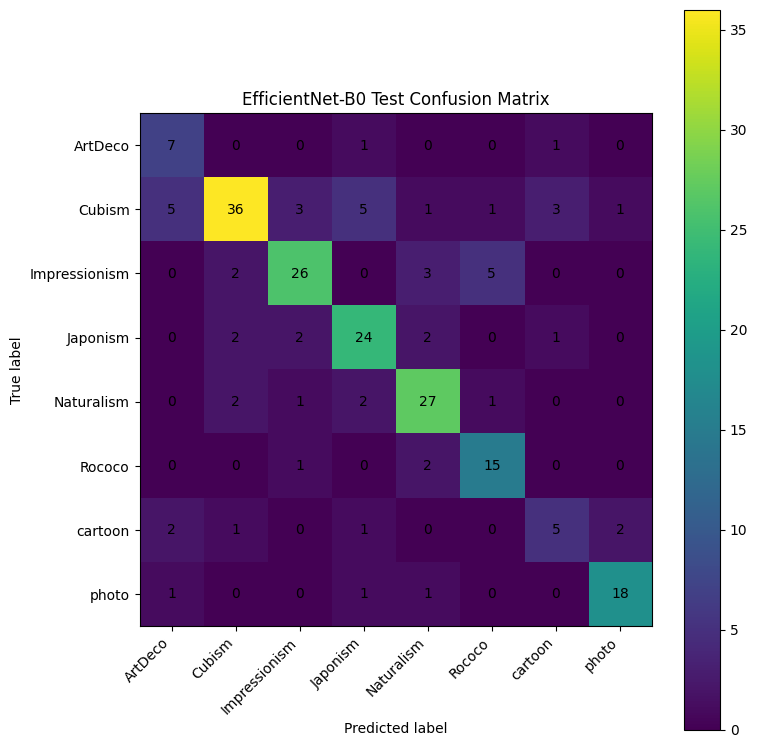

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/efficientnet_b0_test_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/30_efficientnet_b0_test_confusion_matrix.png


In [ ]:
report_text_eff = classification_report(
    y_true_eff,
    y_pred_eff,
    target_names=class_names_eff,
    zero_division=0,
)

print(report_text_eff)

report_path_eff = OUTPUTS_DIR / "efficientnet_b0_test_classification_report.txt"

with open(report_path_eff, "w", encoding="utf-8") as f:
    f.write(report_text_eff)

print(f"Saved classification report to: {report_path_eff}")


cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

cm_eff_df = pd.DataFrame(
    cm_eff,
    index=class_names_eff,
    columns=class_names_eff,
)

cm_path_eff = OUTPUTS_DIR / "efficientnet_b0_test_confusion_matrix.csv"
cm_eff_df.to_csv(cm_path_eff)

display(cm_eff_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_eff)

ax.set_title("EfficientNet-B0 Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names_eff)))
ax.set_yticks(np.arange(len(class_names_eff)))

ax.set_xticklabels(class_names_eff, rotation=45, ha="right")
ax.set_yticklabels(class_names_eff)

for i in range(cm_eff.shape[0]):
    for j in range(cm_eff.shape[1]):
        ax.text(j, i, str(cm_eff[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path_eff = FIGURES_DIR / "30_efficientnet_b0_test_confusion_matrix.png"
fig.savefig(cm_fig_path_eff, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path_eff}")
print(f"Saved confusion matrix figure to: {cm_fig_path_eff}")

In [ ]:
@torch.no_grad()
def evaluate_tta_horizontal_flip(model, loader, criterion, device, return_predictions=False):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        images_flipped = torch.flip(images, dims=[3])

        logits_original = model(images)
        logits_flipped = model(images_flipped)

        logits = (logits_original + logits_flipped) / 2.0

        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


test_metrics_eff_tta, y_true_eff_tta, y_pred_eff_tta = evaluate_tta_horizontal_flip(
    model=model_eff_eval,
    loader=test_loader_eff,
    criterion=criterion_eff,
    device=device,
    return_predictions=True,
)

print("EfficientNet-B0 TTA test metrics:")
for key, value in test_metrics_eff_tta.items():
    print(f"{key}: {value:.4f}")

EfficientNet-B0 TTA test metrics:
accuracy: 0.7477
macro_f1: 0.7185
balanced_accuracy: 0.7437
loss: 1.0172


In [ ]:
comparison_supervised_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss",
        "test_accuracy": 0.5421,
        "test_macro_f1": 0.4947,
        "test_balanced_accuracy": 0.5174,
        "tta": False,
    },
    {
        "model": "ResNet18 transfer learning",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": 0.7570,
        "test_macro_f1": 0.7324,
        "test_balanced_accuracy": 0.7629,
        "tta": False,
    },
    {
        "model": "EfficientNet-B0 transfer learning",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": test_metrics_eff["accuracy"],
        "test_macro_f1": test_metrics_eff["macro_f1"],
        "test_balanced_accuracy": test_metrics_eff["balanced_accuracy"],
        "tta": False,
    },
    {
        "model": "EfficientNet-B0 transfer learning + TTA",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": test_metrics_eff_tta["accuracy"],
        "test_macro_f1": test_metrics_eff_tta["macro_f1"],
        "test_balanced_accuracy": test_metrics_eff_tta["balanced_accuracy"],
        "tta": True,
    },
])

comparison_supervised_path = OUTPUTS_DIR / "supervised_classifier_comparison_final.csv"
comparison_supervised_df.to_csv(comparison_supervised_path, index=False)

display(comparison_supervised_df)

print(f"Saved final supervised comparison table to: {comparison_supervised_path}")

,model,input_size,loss,test_accuracy,test_macro_f1,test_balanced_accuracy,tta
0,SimpleCNN from scratch,128,Weighted CrossEntropyLoss,0.542100,0.494700,0.517400,False
1,ResNet18 transfer learning,128,Weighted CrossEntropyLoss + label smoothing,0.757000,0.732400,0.762900,False
2,EfficientNet-B0 transfer learning,128,Weighted CrossEntropyLoss + label smoothing,0.738318,0.709507,0.736493,False
3,EfficientNet-B0 transfer learning + TTA,128,Weighted CrossEntropyLoss + label smoothing,0.747664,0.718487,0.743745,True


Saved final supervised comparison table to: /content/bostongene_project/image_classification_project/outputs/supervised_classifier_comparison_final.csv


In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/classifier_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved updated classifier results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/classifier_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/classifier_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/classifier_results/reports
Saved updated classifier results to Google Drive: /content/drive/MyDrive/bostongene_project/classifier_results


## ResNet18 Test-Time Augmentation Evaluation

EfficientNet-B0 was evaluated with horizontal-flip test-time augmentation. For a fair comparison, the best ResNet18 transfer-learning model is also evaluated using the same TTA strategy.

The model prediction is computed as the average of:

- prediction on the original image,
- prediction on the horizontally flipped image.

In [ ]:
from torchvision import datasets, transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from src.data import PadToSquare, compute_class_weights
from src.metrics import compute_metrics
from src.config import (
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    NUM_CLASSES,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

IMG_SIZE_RESNET_TTA = 128
BATCH_SIZE_RESNET_TTA = 32
NUM_WORKERS_RESNET_TTA = 2 if device.type == "cuda" else 0

resnet_eval_transform_tta = transforms.Compose([
    PadToSquare(fill=(0, 0, 0)),
    transforms.Resize((IMG_SIZE_RESNET_TTA, IMG_SIZE_RESNET_TTA)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset_resnet_tta = datasets.ImageFolder(
    TRAIN_DIR,
    transform=resnet_eval_transform_tta,
)

test_dataset_resnet_tta = datasets.ImageFolder(
    TEST_DIR,
    transform=resnet_eval_transform_tta,
)

test_loader_resnet_tta = DataLoader(
    test_dataset_resnet_tta,
    batch_size=BATCH_SIZE_RESNET_TTA,
    shuffle=False,
    num_workers=NUM_WORKERS_RESNET_TTA,
    pin_memory=(device.type == "cuda"),
)

class_names_resnet_tta = test_dataset_resnet_tta.classes

print("Test images:", len(test_dataset_resnet_tta))
print("Classes:", class_names_resnet_tta)

Device: cuda
Test images: 214
Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


In [ ]:
from pathlib import Path
import shutil

# Expected checkpoint name
checkpoint_name = "best_resnet18_transfer.pt"

# Possible places where the checkpoint may exist
search_roots = [
    PROJECT_ROOT / "models",
    Path("/content/drive/MyDrive/bostongene_project/classifier_results/models"),
    Path("/content/drive/MyDrive/bostongene_project/classifier_results"),
    Path("/content/drive/MyDrive/bostongene_project"),
    Path("/content"),
]

found_paths = []

for root in search_roots:
    if root.exists():
        found_paths.extend(list(root.rglob(checkpoint_name)))

print("Found checkpoint candidates:")
for p in found_paths:
    print(" -", p)

assert len(found_paths) > 0, (
    "Could not find best_resnet18_transfer.pt. "
    "If it is not in Google Drive, you need to rerun the ResNet18 training cell or re-upload the saved models."
)

# Use the first found checkpoint
source_checkpoint = found_paths[0]

# Copy checkpoint into current runtime project models folder
MODELS_DIR.mkdir(parents=True, exist_ok=True)
target_checkpoint = MODELS_DIR / checkpoint_name

shutil.copy2(source_checkpoint, target_checkpoint)

print("Copied checkpoint:")
print("From:", source_checkpoint)
print("To:  ", target_checkpoint)

best_resnet_path = target_checkpoint
print("Ready to load:", best_resnet_path)

Found checkpoint candidates:
 - /content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt
 - /content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt
 - /content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt
 - /content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt
Copied checkpoint:
From: /content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt
To:   /content/bostongene_project/image_classification_project/models/best_resnet18_transfer.pt
Ready to load: /content/bostongene_project/image_classification_project/models/best_resnet18_transfer.pt


In [ ]:
best_resnet_path = MODELS_DIR / "best_resnet18_transfer.pt"

assert best_resnet_path.exists(), f"ResNet18 checkpoint not found: {best_resnet_path}"

checkpoint_resnet = torch.load(best_resnet_path, map_location=device)

model_resnet_tta = resnet18(weights=None)

in_features = model_resnet_tta.fc.in_features

model_resnet_tta.fc = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, NUM_CLASSES),
)

model_resnet_tta = model_resnet_tta.to(device)
model_resnet_tta.load_state_dict(checkpoint_resnet["model_state_dict"])

class_weights_resnet_tta = compute_class_weights(train_dataset_resnet_tta).to(device)

criterion_resnet_tta = nn.CrossEntropyLoss(
    weight=class_weights_resnet_tta,
    label_smoothing=0.05,
)

print("Loaded ResNet18 checkpoint:")
print("Best checkpoint epoch:", checkpoint_resnet["epoch"])
print("Validation macro-F1:", checkpoint_resnet["val_macro_f1"])

Loaded ResNet18 checkpoint:
Best checkpoint epoch: 13
Validation macro-F1: 0.6848858707798187


In [ ]:
@torch.no_grad()
def evaluate_tta_horizontal_flip(model, loader, criterion, device, return_predictions=False):
    """
    Evaluate model using horizontal-flip test-time augmentation.

    Prediction = average(logits(original image), logits(flipped image))
    """
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        images_flipped = torch.flip(images, dims=[3])

        logits_original = model(images)
        logits_flipped = model(images_flipped)

        logits = (logits_original + logits_flipped) / 2.0

        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics


test_metrics_resnet_tta, y_true_resnet_tta, y_pred_resnet_tta = evaluate_tta_horizontal_flip(
    model=model_resnet_tta,
    loader=test_loader_resnet_tta,
    criterion=criterion_resnet_tta,
    device=device,
    return_predictions=True,
)

print("ResNet18 + TTA test metrics:")
for key, value in test_metrics_resnet_tta.items():
    print(f"{key}: {value:.4f}")

ResNet18 + TTA test metrics:
accuracy: 0.7757
macro_f1: 0.7479
balanced_accuracy: 0.7736
loss: 1.0400


               precision    recall  f1-score   support

      ArtDeco       0.46      0.67      0.55         9
       Cubism       0.81      0.84      0.82        55
Impressionism       0.87      0.72      0.79        36
     Japonism       0.81      0.71      0.76        31
   Naturalism       0.83      0.76      0.79        33
       Rococo       0.70      0.78      0.74        18
      cartoon       0.56      0.91      0.69        11
        photo       0.89      0.81      0.85        21

     accuracy                           0.78       214
    macro avg       0.74      0.77      0.75       214
 weighted avg       0.79      0.78      0.78       214

Saved classification report to: /content/bostongene_project/image_classification_project/outputs/resnet18_tta_test_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,6,2,0,0,0,0,1,0
Cubism,3,46,2,1,0,0,3,0
Impressionism,0,1,26,2,1,4,2,0
Japonism,1,4,1,22,1,0,1,1
Naturalism,2,3,0,1,25,1,0,1
Rococo,0,0,1,1,2,14,0,0
cartoon,0,1,0,0,0,0,10,0
photo,1,0,0,0,1,1,1,17


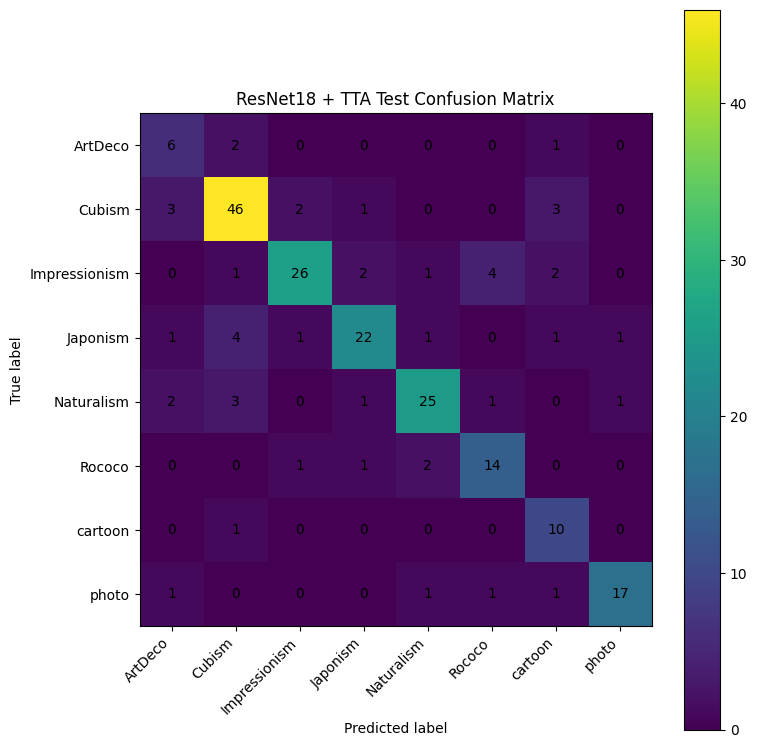

Saved confusion matrix CSV to: /content/bostongene_project/image_classification_project/outputs/resnet18_tta_test_confusion_matrix.csv
Saved confusion matrix figure to: /content/bostongene_project/image_classification_project/reports/figures/31_resnet18_tta_test_confusion_matrix.png


In [ ]:
report_text_resnet_tta = classification_report(
    y_true_resnet_tta,
    y_pred_resnet_tta,
    target_names=class_names_resnet_tta,
    zero_division=0,
)

print(report_text_resnet_tta)

report_path_resnet_tta = OUTPUTS_DIR / "resnet18_tta_test_classification_report.txt"

with open(report_path_resnet_tta, "w", encoding="utf-8") as f:
    f.write(report_text_resnet_tta)

print(f"Saved classification report to: {report_path_resnet_tta}")


cm_resnet_tta = confusion_matrix(y_true_resnet_tta, y_pred_resnet_tta)

cm_resnet_tta_df = pd.DataFrame(
    cm_resnet_tta,
    index=class_names_resnet_tta,
    columns=class_names_resnet_tta,
)

cm_path_resnet_tta = OUTPUTS_DIR / "resnet18_tta_test_confusion_matrix.csv"
cm_resnet_tta_df.to_csv(cm_path_resnet_tta)

display(cm_resnet_tta_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_resnet_tta)

ax.set_title("ResNet18 + TTA Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names_resnet_tta)))
ax.set_yticks(np.arange(len(class_names_resnet_tta)))

ax.set_xticklabels(class_names_resnet_tta, rotation=45, ha="right")
ax.set_yticklabels(class_names_resnet_tta)

for i in range(cm_resnet_tta.shape[0]):
    for j in range(cm_resnet_tta.shape[1]):
        ax.text(j, i, str(cm_resnet_tta[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path_resnet_tta = FIGURES_DIR / "31_resnet18_tta_test_confusion_matrix.png"
fig.savefig(cm_fig_path_resnet_tta, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path_resnet_tta}")
print(f"Saved confusion matrix figure to: {cm_fig_path_resnet_tta}")

In [ ]:
# Existing known results
simple_accuracy = 0.5421
simple_macro_f1 = 0.4947
simple_balanced_accuracy = 0.5174

resnet_accuracy = 0.7570
resnet_macro_f1 = 0.7324
resnet_balanced_accuracy = 0.7629

# EfficientNet values: use variables if they exist, otherwise keep your known values.
if "test_metrics_eff" in globals():
    eff_accuracy = test_metrics_eff["accuracy"]
    eff_macro_f1 = test_metrics_eff["macro_f1"]
    eff_balanced_accuracy = test_metrics_eff["balanced_accuracy"]
else:
    eff_accuracy = 0.7383
    eff_macro_f1 = 0.7095
    eff_balanced_accuracy = 0.7365

if "test_metrics_eff_tta" in globals():
    eff_tta_accuracy = test_metrics_eff_tta["accuracy"]
    eff_tta_macro_f1 = test_metrics_eff_tta["macro_f1"]
    eff_tta_balanced_accuracy = test_metrics_eff_tta["balanced_accuracy"]
else:
    eff_tta_accuracy = 0.7477
    eff_tta_macro_f1 = 0.7185
    eff_tta_balanced_accuracy = 0.7437


comparison_supervised_final_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss",
        "test_accuracy": simple_accuracy,
        "test_macro_f1": simple_macro_f1,
        "test_balanced_accuracy": simple_balanced_accuracy,
        "tta": False,
    },
    {
        "model": "ResNet18 transfer learning",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": resnet_accuracy,
        "test_macro_f1": resnet_macro_f1,
        "test_balanced_accuracy": resnet_balanced_accuracy,
        "tta": False,
    },
    {
        "model": "ResNet18 transfer learning + TTA",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": test_metrics_resnet_tta["accuracy"],
        "test_macro_f1": test_metrics_resnet_tta["macro_f1"],
        "test_balanced_accuracy": test_metrics_resnet_tta["balanced_accuracy"],
        "tta": True,
    },
    {
        "model": "EfficientNet-B0 transfer learning",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": eff_accuracy,
        "test_macro_f1": eff_macro_f1,
        "test_balanced_accuracy": eff_balanced_accuracy,
        "tta": False,
    },
    {
        "model": "EfficientNet-B0 transfer learning + TTA",
        "input_size": 128,
        "loss": "Weighted CrossEntropyLoss + label smoothing",
        "test_accuracy": eff_tta_accuracy,
        "test_macro_f1": eff_tta_macro_f1,
        "test_balanced_accuracy": eff_tta_balanced_accuracy,
        "tta": True,
    },
])

comparison_supervised_final_path = OUTPUTS_DIR / "supervised_classifier_comparison_with_resnet_tta.csv"
comparison_supervised_final_df.to_csv(comparison_supervised_final_path, index=False)

display(comparison_supervised_final_df)

print(f"Saved final supervised comparison table to: {comparison_supervised_final_path}")

,model,input_size,loss,test_accuracy,test_macro_f1,test_balanced_accuracy,tta
0,SimpleCNN from scratch,128,Weighted CrossEntropyLoss,0.542100,0.494700,0.517400,False
1,ResNet18 transfer learning,128,Weighted CrossEntropyLoss + label smoothing,0.757000,0.732400,0.762900,False
2,ResNet18 transfer learning + TTA,128,Weighted CrossEntropyLoss + label smoothing,0.775701,0.747941,0.773612,True
3,EfficientNet-B0 transfer learning,128,Weighted CrossEntropyLoss + label smoothing,0.738318,0.709507,0.736493,False
4,EfficientNet-B0 transfer learning + TTA,128,Weighted CrossEntropyLoss + label smoothing,0.747664,0.718487,0.743745,True


Saved final supervised comparison table to: /content/bostongene_project/image_classification_project/outputs/supervised_classifier_comparison_with_resnet_tta.csv


## Final Supervised Classifier Selection

Several supervised classification models were evaluated. The SimpleCNN trained from scratch served as the baseline. Transfer learning significantly improved performance, confirming that pretrained visual features are highly useful for the small and imbalanced painting-style dataset.

ResNet18 transfer learning achieved the strongest supervised result before test-time augmentation. EfficientNet-B0 was also evaluated and improved slightly with horizontal-flip TTA, but it did not outperform ResNet18.

The final supervised model is selected based on macro-F1 and balanced accuracy, because the dataset is imbalanced. If ResNet18 + TTA improves over regular ResNet18, it is selected as the final supervised classifier. Otherwise, the regular ResNet18 checkpoint remains the final supervised classifier.

In [ ]:
from pathlib import Path
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DRIVE_RESULTS_DIR = Path("/content/drive/MyDrive/bostongene_project/classifier_results")
    DRIVE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    for folder_name in ["models", "outputs", "reports"]:
        src = PROJECT_ROOT / folder_name
        dst = DRIVE_RESULTS_DIR / folder_name

        if src.exists():
            shutil.copytree(src, dst, dirs_exist_ok=True)
            print(f"Copied {src} -> {dst}")

    print("Saved updated classifier results to Google Drive:", DRIVE_RESULTS_DIR)
else:
    print("Not running in Colab, no Drive backup needed.")

Copied /content/bostongene_project/image_classification_project/models -> /content/drive/MyDrive/bostongene_project/classifier_results/models
Copied /content/bostongene_project/image_classification_project/outputs -> /content/drive/MyDrive/bostongene_project/classifier_results/outputs
Copied /content/bostongene_project/image_classification_project/reports -> /content/drive/MyDrive/bostongene_project/classifier_results/reports
Saved updated classifier results to Google Drive: /content/drive/MyDrive/bostongene_project/classifier_results


## Final Supervised Classifier Conclusion

The supervised classification stage evaluated several models: a SimpleCNN trained from scratch, ResNet18 transfer learning, EfficientNet-B0 transfer learning, and test-time augmentation variants.

The SimpleCNN baseline achieved 54.21% test accuracy and 49.47% macro-F1, showing that the dataset contains learnable visual signal but that training from scratch is limited by the small and imbalanced dataset.

Transfer learning significantly improved performance. ResNet18 achieved 75.70% test accuracy and 73.24% macro-F1. EfficientNet-B0 was also evaluated and achieved 70.95% macro-F1, improving to 71.85% macro-F1 with horizontal-flip test-time augmentation.

For a fair comparison, the ResNet18 model was also evaluated with horizontal-flip TTA. This produced the best supervised result: 77.57% test accuracy, 74.79% macro-F1, and 77.36% balanced accuracy. Therefore, ResNet18 with test-time augmentation was selected as the final supervised classifier.

The model performs especially well on Cubism, Impressionism, Naturalism, photo, Japonism, and Rococo. ArtDeco remains the most difficult class, mainly because it has the smallest number of test samples.

## XAI: Grad-CAM on the supervised classifier

Grad-CAM highlights which image regions drive the ResNet18 style prediction. We
overlay the heatmap on test images — both correct and misclassified — to see *what*
the model attends to for each style (e.g. brushstroke texture, geometric edges,
figures), which directly addresses the "features that separate the classes"
requirement.

In [9]:
from pathlib import Path
print("In MODELS_DIR:", list(MODELS_DIR.glob("*.pt")))
for d in [
    Path("/content/drive/MyDrive/bostongene_project/classifier_results/models"),
    Path("/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models"),
]:
    print(d, "->", list(d.glob("*.pt")) if d.exists() else "MISSING")

In MODELS_DIR: [PosixPath('/content/bostongene_project/image_classification_project/models/best_simple_cnn.pt')]
/content/drive/MyDrive/bostongene_project/classifier_results/models -> [PosixPath('/content/drive/MyDrive/bostongene_project/classifier_results/models/best_resnet18_transfer.pt'), PosixPath('/content/drive/MyDrive/bostongene_project/classifier_results/models/best_efficientnet_b0_transfer.pt'), PosixPath('/content/drive/MyDrive/bostongene_project/classifier_results/models/best_simple_cnn.pt')]
/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models -> [PosixPath('/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models/best_class_regularized_vae_v2.pt'), PosixPath('/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models/best_class_regularized_vae.pt'), PosixPath('/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models/best_simple_cnn.pt')]


In [11]:
import shutil
from pathlib import Path

target = MODELS_DIR / "best_resnet18_transfer.pt"
if not target.exists():
    for d in [
        Path("/content/drive/MyDrive/bostongene_project/classifier_results/models"),
        Path("/content/drive/MyDrive/bostongene_project/class_regularized_vae_results/models"),
    ]:
        cand = d / "best_resnet18_transfer.pt"
        if cand.exists():
            MODELS_DIR.mkdir(parents=True, exist_ok=True)
            shutil.copy2(cand, target)
            print("Restored checkpoint from", d)
            break
assert target.exists(), "Checkpoint not found locally or in Drive backups."

Restored checkpoint from /content/drive/MyDrive/bostongene_project/classifier_results/models


In [13]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn

# --- Rebuild the ResNet18 transfer model exactly as trained, then load weights ---
from torchvision import models as tvmodels
from src.config import MODELS_DIR # Import MODELS_DIR

gradcam_model = tvmodels.resnet18(weights=None)

# Load checkpoint first to get class_names
ckpt = torch.load(MODELS_DIR / "best_resnet18_transfer.pt", map_location=device)
class_names = ckpt["class_names"]

# Rebuild the final layer exactly as it was during training
in_features = gradcam_model.fc.in_features
gradcam_model.fc = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(in_features, len(class_names)),
)
gradcam_model.load_state_dict(ckpt["model_state_dict"])
gradcam_model.to(device).eval()

# Last convolutional block of ResNet18:
target_layer = gradcam_model.layer4[-1]

# --- Hooks to capture activations + gradients of that layer ---
_feats, _grads = {}, {}
def fwd_hook(m, i, o): _feats["v"] = o.detach()
def bwd_hook(m, gi, go): _grads["v"] = go[0].detach()
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

def gradcam_for(x):
    """x: (1,3,H,W) normalized tensor -> (cam[H,W] in 0..1, predicted_class)."""
    gradcam_model.zero_grad()
    logits = gradcam_model(x)
    cls = int(logits.argmax(1))
    logits[0, cls].backward()
    w = _grads["v"].mean(dim=(2, 3), keepdim=True)      # GAP over gradients
    cam = F.relu((w * _feats["v"]).sum(1, keepdim=True)) # weighted sum, ReLU
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.cpu().numpy(), cls

In [15]:
from src.config import FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "40_resnet18_gradcam.png", dpi=150, bbox_inches="tight")
print("Saved:", FIGURES_DIR / "40_resnet18_gradcam.png")

Saved: /content/bostongene_project/image_classification_project/reports/figures/40_resnet18_gradcam.png


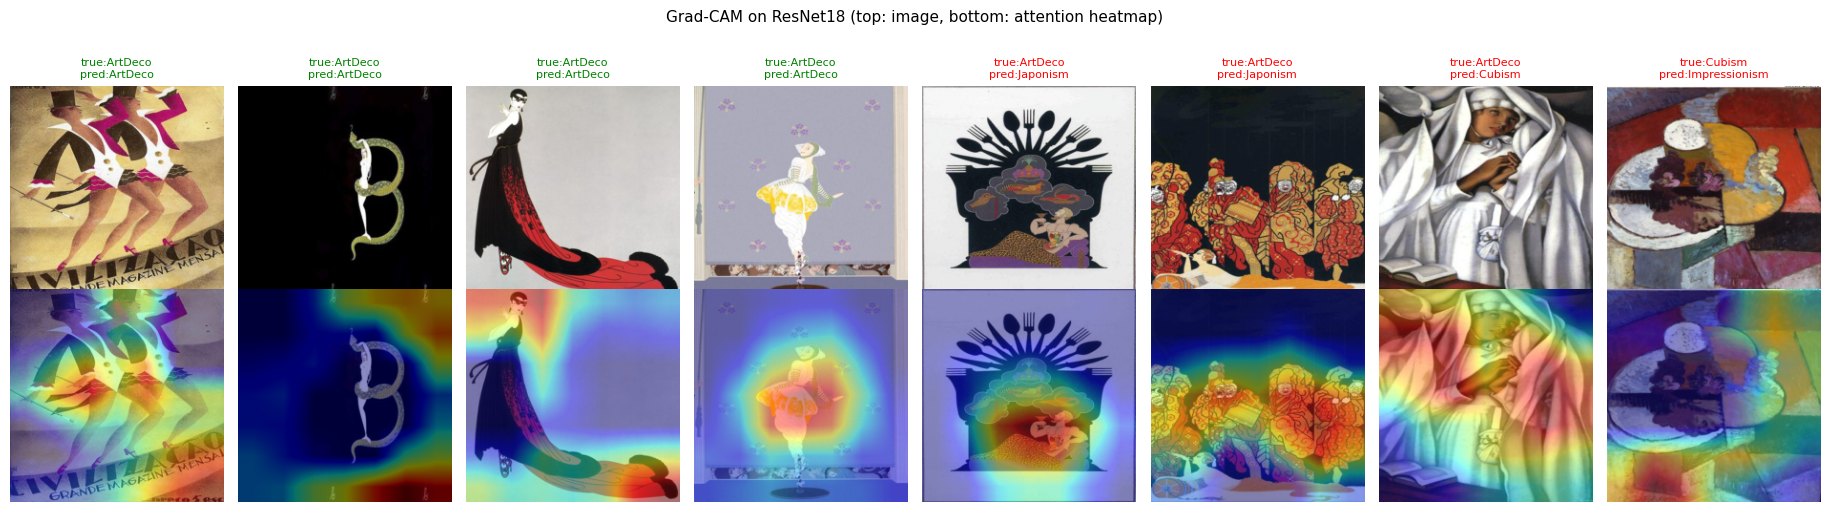

In [16]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

# Self-contained test transform (match the image size your ResNet18 was trained at: 224 or 128)
gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_ds_gc = ImageFolder(TEST_DIR, transform=gradcam_transform)

def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Collect a few correct and a few misclassified predictions to show both behaviours
# Shuffle test indices with a fixed seed so the grid samples across style classes
rng_gc = np.random.default_rng(42)
all_test_idx = list(range(len(test_ds_gc)))
rng_gc.shuffle(all_test_idx)

correct_idx, wrong_idx = [], []
for i in all_test_idx:
    x, y = test_ds_gc[i]
    _, pred = gradcam_for(x.unsqueeze(0).to(device))
    (correct_idx if pred == y else wrong_idx).append(i)
    if len(correct_idx) >= 4 and len(wrong_idx) >= 4:
        break

show = correct_idx[:4] + wrong_idx[:4]
fig, axes = plt.subplots(2, len(show), figsize=(2.3 * len(show), 5.2))
for col, idx in enumerate(show):
    x, y = test_ds_gc[idx]
    cam, pred = gradcam_for(x.unsqueeze(0).to(device))
    base = denorm(x)
    axes[0, col].imshow(base); axes[0, col].axis("off")
    ok = (pred == y)
    axes[0, col].set_title(f"true:{class_names[y]}\npred:{class_names[pred]}",
                           fontsize=8, color="green" if ok else "red")
    axes[1, col].imshow(base); axes[1, col].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, col].axis("off")
fig.suptitle("Grad-CAM on ResNet18 (top: image, bottom: attention heatmap)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURES_DIR / "40_resnet18_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()

h1.remove(); h2.remove()   # clean up the hooks